In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib as mpl
from scipy.stats import mannwhitneyu
from matplotlib.ticker import PercentFormatter

# ---- Adobe-friendly fonts (must be set BEFORE plotting) ----
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42

base = '/Volumes/lab-windingm/home/users/cochral/LRS/AttractionRig/analysis/social-isolation/sensory'
plot_dir = '/Users/cochral/repos/behavioural-analysis/plots/lrs_paper/sensory-mutants'

conditions = ['wiii8', 'anosmic', '9047', '23129', '33300']
source_order = ['real', 'pseudo']

condition_colors = {
    'wiii8': '#385491',
    'anosmic': '#be0f0a',
    '9047': '#e7533a',
    '23129': '#fc8c59',
    '33300': "#fead61",
}
pseudo_colour = '#c4c4c4'

# Real dishes and their pseudo dishes, which hold larvae that never actually shared a plate.
real = pd.concat(
    [pd.read_csv(f'{base}/{c}/interaction_type_bout.csv').assign(condition=c, source='real') for c in conditions],
    ignore_index=True,
)

pseudo = pd.concat(
    [pd.read_csv(f'{base}/{c}-pseudo/interaction_type_bout.csv').assign(condition=c, source='pseudo') for c in conditions],
    ignore_index=True,
)

df = pd.concat([real, pseudo], ignore_index=True)

print(df.groupby(['condition', 'source'])['file'].nunique().unstack()[source_order].loc[conditions])

source     real  pseudo
condition              
wiii8        10     100
anosmic      10     100
9047         10     100
23129        10     100
33300        10     100


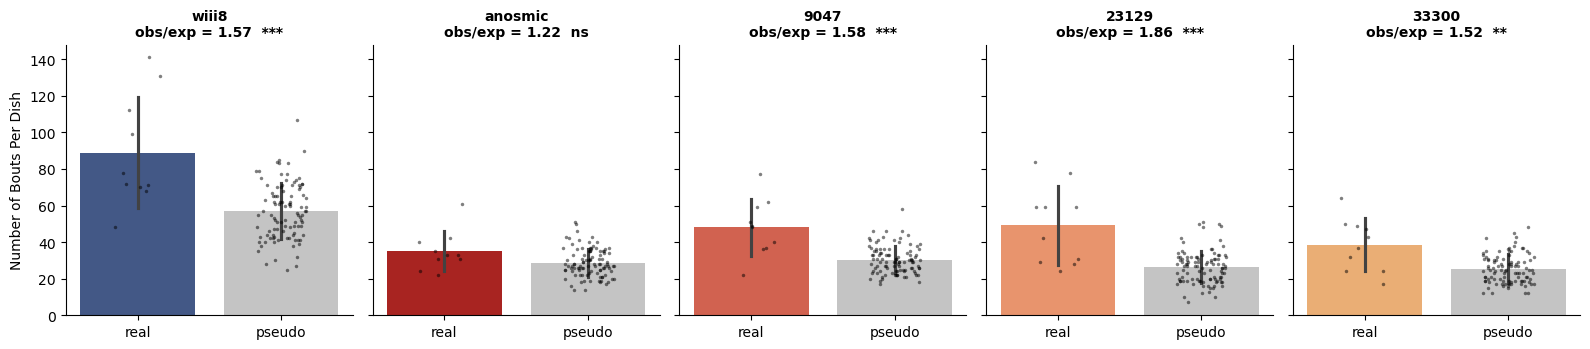

condition  real_mean  pseudo_mean  obs_over_exp     U        p significance
    wiii8       89.0        56.83      1.566074 840.0 0.000414          ***
  anosmic       35.2        28.83      1.220950 681.5 0.059523           ns
     9047       48.1        30.39      1.582757 858.5 0.000194          ***
    23129       49.3        26.50      1.860377 826.5 0.000691          ***
    33300       38.7        25.42      1.522423 776.5 0.004066           **


In [2]:
# Bouts per dish: real versus its own pseudo null.
bout_counts = (
    df.groupby(['condition', 'source', 'file'], as_index=False)
      .size()
      .rename(columns={'size': 'n_bouts'})
)

fig, axes = plt.subplots(1, 5, figsize=(16, 3.6), sharey=True)
stats_rows = []

for ax, condition in zip(axes, conditions):

    plot_data = bout_counts[bout_counts['condition'] == condition]
    real_values = plot_data.loc[plot_data['source'] == 'real', 'n_bouts']
    pseudo_values = plot_data.loc[plot_data['source'] == 'pseudo', 'n_bouts']

    u_stat, p_value = mannwhitneyu(real_values, pseudo_values, alternative='two-sided')
    ratio = real_values.mean() / pseudo_values.mean()
    stars = '***' if p_value < 0.001 else '**' if p_value < 0.01 else '*' if p_value < 0.05 else 'ns'

    stats_rows.append({
        'condition': condition,
        'real_mean': real_values.mean(),
        'pseudo_mean': pseudo_values.mean(),
        'obs_over_exp': ratio,
        'U': u_stat,
        'p': p_value,
        'significance': stars,
    })

    sns.barplot(
        data=plot_data, x='source', y='n_bouts', order=source_order,
        hue='source', hue_order=source_order,
        palette={'real': condition_colors[condition], 'pseudo': pseudo_colour},
        errorbar='sd', legend=False, ax=ax,
    )
    sns.stripplot(
        data=plot_data, x='source', y='n_bouts', order=source_order,
        color='black', size=2.5, jitter=0.18, alpha=0.5, ax=ax,
    )

    ax.set_title(f'{condition}\nobs/exp = {ratio:.2f}  {stars}', fontsize=10, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('Number of Bouts Per Dish' if condition == conditions[0] else '')

plt.ylim(0, None)
sns.despine()
plt.tight_layout()
plt.savefig(f'{plot_dir}/pseudo_interaction_bouts_count.pdf', format='pdf')
plt.show()

print(pd.DataFrame(stats_rows).to_string(index=False))

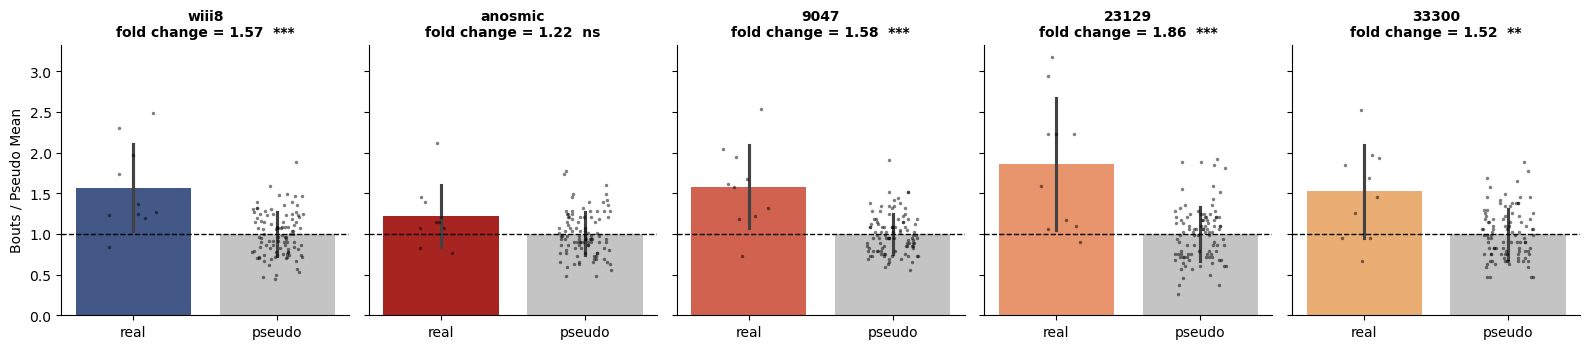

condition  real_fold_change  pseudo_fold_change     U        p significance
    wiii8          1.566074                 1.0 840.0 0.000414          ***
  anosmic          1.220950                 1.0 681.5 0.059523           ns
     9047          1.582757                 1.0 858.5 0.000194          ***
    23129          1.860377                 1.0 826.5 0.000691          ***
    33300          1.522423                 1.0 776.5 0.004066           **


In [3]:
# Same bout counts, but every dish divided by its own condition's pseudo mean, so 1 is the null.
pseudo_mean_per_condition = (
    bout_counts[bout_counts['source'] == 'pseudo']
    .groupby('condition')['n_bouts']
    .mean()
    .rename('pseudo_mean')
)

fold_counts = bout_counts.merge(pseudo_mean_per_condition, on='condition')
fold_counts['fold_change'] = fold_counts['n_bouts'] / fold_counts['pseudo_mean']

fig, axes = plt.subplots(1, 5, figsize=(16, 3.6), sharey=True)
stats_rows = []

for ax, condition in zip(axes, conditions):

    plot_data = fold_counts[fold_counts['condition'] == condition]
    real_values = plot_data.loc[plot_data['source'] == 'real', 'fold_change']
    pseudo_values = plot_data.loc[plot_data['source'] == 'pseudo', 'fold_change']

    u_stat, p_value = mannwhitneyu(real_values, pseudo_values, alternative='two-sided')
    stars = '***' if p_value < 0.001 else '**' if p_value < 0.01 else '*' if p_value < 0.05 else 'ns'

    stats_rows.append({
        'condition': condition,
        'real_fold_change': real_values.mean(),
        'pseudo_fold_change': pseudo_values.mean(),
        'U': u_stat,
        'p': p_value,
        'significance': stars,
    })

    sns.barplot(
        data=plot_data, x='source', y='fold_change', order=source_order,
        hue='source', hue_order=source_order,
        palette={'real': condition_colors[condition], 'pseudo': pseudo_colour},
        errorbar='sd', legend=False, ax=ax,
    )
    sns.stripplot(
        data=plot_data, x='source', y='fold_change', order=source_order,
        color='black', size=2.5, jitter=0.18, alpha=0.5, ax=ax,
    )

    ax.axhline(1, color='black', linestyle='--', linewidth=1)

    ax.set_title(f'{condition}\nfold change = {real_values.mean():.2f}  {stars}', fontsize=10, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('Bouts / Pseudo Mean' if condition == conditions[0] else '')

plt.ylim(0, None)
sns.despine()
plt.tight_layout()
plt.savefig(f'{plot_dir}/pseudo_interaction_bouts_count_fold-change.pdf', format='pdf')
plt.show()

print(pd.DataFrame(stats_rows).to_string(index=False))

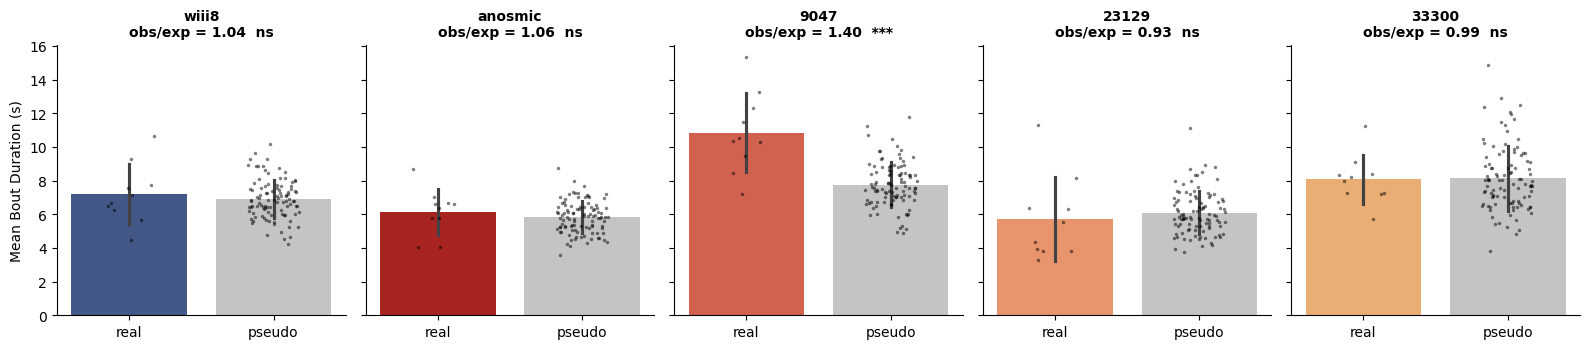

condition  real_mean  pseudo_mean  obs_over_exp     U        p significance
    wiii8   7.194190     6.908701      1.041323 539.0 0.688932           ns
  anosmic   6.156657     5.825160      1.056908 594.0 0.330959           ns
     9047  10.857696     7.763863      1.398491 884.0 0.000067          ***
    23129   5.693314     6.104426      0.932653 362.5 0.154308           ns
    33300   8.080299     8.140027      0.992662 514.5 0.884264           ns


In [4]:
# Mean bout duration per dish: real versus its own pseudo null.
duration_per_file = (
    df.groupby(['condition', 'source', 'file'], as_index=False)['duration']
      .mean()
      .rename(columns={'duration': 'mean_bout_duration'})
)

fig, axes = plt.subplots(1, 5, figsize=(16, 3.6), sharey=True)
stats_rows = []

for ax, condition in zip(axes, conditions):

    plot_data = duration_per_file[duration_per_file['condition'] == condition]
    real_values = plot_data.loc[plot_data['source'] == 'real', 'mean_bout_duration']
    pseudo_values = plot_data.loc[plot_data['source'] == 'pseudo', 'mean_bout_duration']

    u_stat, p_value = mannwhitneyu(real_values, pseudo_values, alternative='two-sided')
    ratio = real_values.mean() / pseudo_values.mean()
    stars = '***' if p_value < 0.001 else '**' if p_value < 0.01 else '*' if p_value < 0.05 else 'ns'

    stats_rows.append({
        'condition': condition,
        'real_mean': real_values.mean(),
        'pseudo_mean': pseudo_values.mean(),
        'obs_over_exp': ratio,
        'U': u_stat,
        'p': p_value,
        'significance': stars,
    })

    sns.barplot(
        data=plot_data, x='source', y='mean_bout_duration', order=source_order,
        hue='source', hue_order=source_order,
        palette={'real': condition_colors[condition], 'pseudo': pseudo_colour},
        errorbar='sd', legend=False, ax=ax,
    )
    sns.stripplot(
        data=plot_data, x='source', y='mean_bout_duration', order=source_order,
        color='black', size=2.5, jitter=0.18, alpha=0.5, ax=ax,
    )

    ax.set_title(f'{condition}\nobs/exp = {ratio:.2f}  {stars}', fontsize=10, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('Mean Bout Duration (s)' if condition == conditions[0] else '')

plt.ylim(0, None)
sns.despine()
plt.tight_layout()
plt.savefig(f'{plot_dir}/pseudo_interaction_bouts_duration.pdf', format='pdf')
plt.show()

print(pd.DataFrame(stats_rows).to_string(index=False))

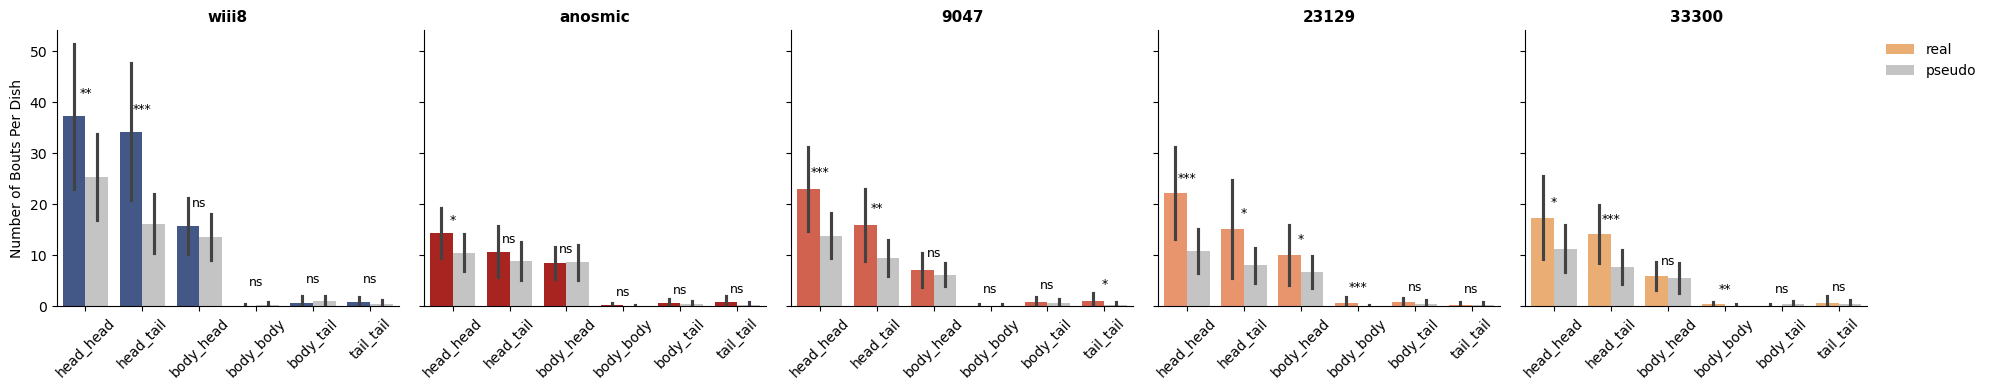

condition initial_type  real_mean  pseudo_mean  obs_over_exp     U        p significance
    wiii8    head_head       37.3        25.32      1.473144 780.5 0.003569           **
    wiii8    head_tail       34.2        16.21      2.109809 928.5 0.000008          ***
    wiii8    body_head       15.8        13.57      1.164333 609.5 0.255687           ns
    wiii8    body_body        0.1         0.33      0.303030 407.5 0.213116           ns
    wiii8    body_tail        0.7         0.92      0.760870 403.5 0.284504           ns
    wiii8    tail_tail        0.9         0.48      1.875000 629.0 0.119671           ns
  anosmic    head_head       14.3        10.49      1.363203 732.5 0.015417            *
  anosmic    head_tail       10.7         8.92      1.199552 598.5 0.305641           ns
  anosmic    body_head        8.5         8.64      0.983796 517.0 0.863090           ns
  anosmic    body_body        0.2         0.07      2.857143 565.0 0.157772           ns
  anosmic    body_tai

In [5]:
# Bouts per dish split by how the contact started.
initial_type_order = ['head_head', 'head_tail', 'body_head', 'body_body', 'body_tail', 'tail_tail']

counts = (
    df.groupby(['condition', 'source', 'file', 'initial_type'], as_index=False)
      .size()
      .rename(columns={'size': 'count'})
)

# Dishes with none of a given type count as zero, not missing.
dishes = df[['condition', 'source', 'file']].drop_duplicates()
counts = (
    dishes.merge(pd.DataFrame({'initial_type': initial_type_order}), how='cross')
          .merge(counts, on=['condition', 'source', 'file', 'initial_type'], how='left')
)
counts['count'] = counts['count'].fillna(0)

fig, axes = plt.subplots(1, 5, figsize=(20, 4), sharey=True)
stats_rows = []

for ax, condition in zip(axes, conditions):

    plot_data = counts[counts['condition'] == condition]

    sns.barplot(
        data=plot_data, x='initial_type', y='count', order=initial_type_order,
        hue='source', hue_order=source_order,
        palette={'real': condition_colors[condition], 'pseudo': pseudo_colour},
        errorbar='sd', legend=(condition == conditions[-1]), ax=ax,
    )

    y_offset = plot_data['count'].max() * 0.05

    for position, initial_type in enumerate(initial_type_order):
        real_values = plot_data.loc[(plot_data['source'] == 'real') & (plot_data['initial_type'] == initial_type), 'count']
        pseudo_values = plot_data.loc[(plot_data['source'] == 'pseudo') & (plot_data['initial_type'] == initial_type), 'count']

        u_stat, p_value = mannwhitneyu(real_values, pseudo_values, alternative='two-sided')
        stars = '***' if p_value < 0.001 else '**' if p_value < 0.01 else '*' if p_value < 0.05 else 'ns'

        stats_rows.append({
            'condition': condition,
            'initial_type': initial_type,
            'real_mean': real_values.mean(),
            'pseudo_mean': pseudo_values.mean(),
            'obs_over_exp': real_values.mean() / pseudo_values.mean() if pseudo_values.mean() else np.nan,
            'U': u_stat,
            'p': p_value,
            'significance': stars,
        })

        ax.text(position, max(real_values.mean(), pseudo_values.mean()) + y_offset, stars,
                ha='center', va='bottom', fontsize=9)

    ax.set_title(condition, fontsize=11, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('Number of Bouts Per Dish' if condition == conditions[0] else '')
    ax.tick_params(axis='x', rotation=45)

axes[-1].legend(frameon=False, title=None, bbox_to_anchor=(1.02, 1), loc='upper left')
plt.ylim(0, None)
sns.despine()
plt.tight_layout()
plt.savefig(f'{plot_dir}/pseudo_interaction_bouts_initiation_count.pdf', format='pdf', bbox_inches='tight')
plt.show()

print(pd.DataFrame(stats_rows).to_string(index=False))

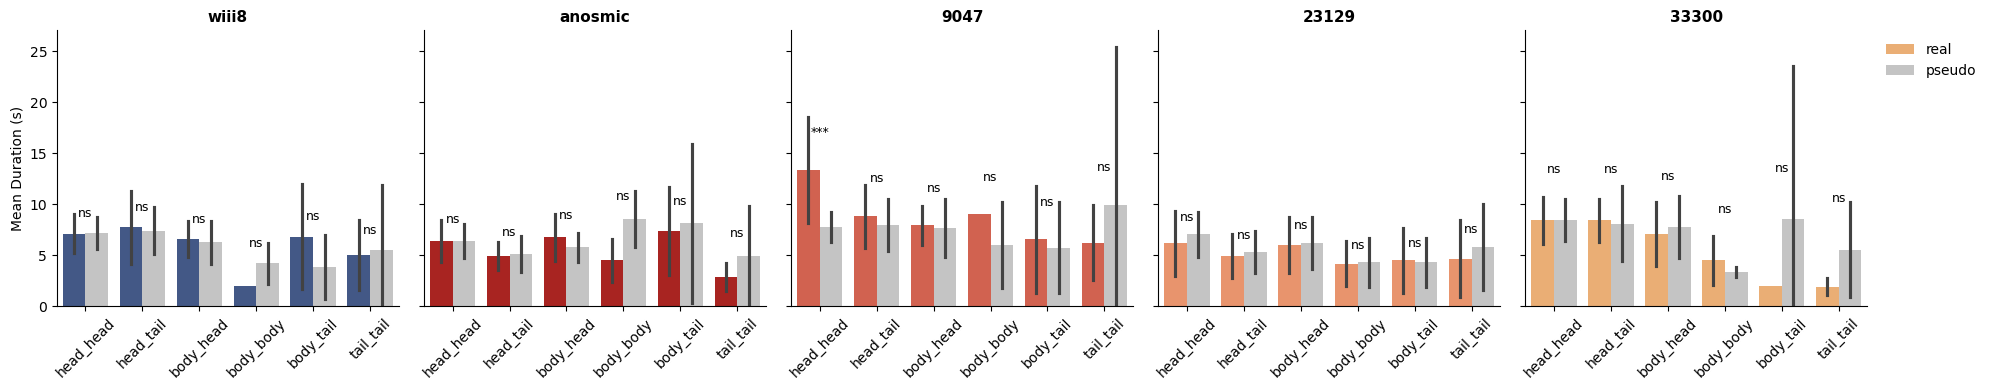

condition initial_type  real_mean  pseudo_mean  obs_over_exp     U        p significance
    wiii8    head_head   7.102376     7.181794      0.988942 454.5 0.639858           ns
    wiii8    head_tail   7.722350     7.420493      1.040679 452.5 0.625060           ns
    wiii8    body_head   6.597929     6.257541      1.054396 605.5 0.274928           ns
    wiii8    body_body   2.000000     4.196429      0.476596   4.0 0.246771           ns
    wiii8    body_tail   6.812500     3.836207      1.775843 173.5 0.097565           ns
    wiii8    tail_tail   5.027778     5.523810      0.910201 120.0 0.590289           ns
  anosmic    head_head   6.353233     6.375814      0.996458 508.0 0.937835           ns
  anosmic    head_tail   4.948281     5.120211      0.966421 477.0 0.814989           ns
  anosmic    body_head   6.740794     5.796025      1.163003 605.0 0.277211           ns
  anosmic    body_body   4.500000     8.571429      0.525000   1.0 0.091117           ns
  anosmic    body_tai

In [7]:
# Mean duration of each initiation type.
duration_by_type = (
    df.groupby(['condition', 'source', 'file', 'initial_type'], as_index=False)['duration']
      .mean()
)

fig, axes = plt.subplots(1, 5, figsize=(20, 4), sharey=True)
stats_rows = []

for ax, condition in zip(axes, conditions):

    plot_data = duration_by_type[duration_by_type['condition'] == condition]

    sns.barplot(
        data=plot_data, x='initial_type', y='duration', order=initial_type_order,
        hue='source', hue_order=source_order,
        palette={'real': condition_colors[condition], 'pseudo': pseudo_colour},
        errorbar='sd', legend=(condition == conditions[-1]), ax=ax,
    )

    y_offset = plot_data['duration'].max() * 0.05

    for position, initial_type in enumerate(initial_type_order):
        real_values = plot_data.loc[(plot_data['source'] == 'real') & (plot_data['initial_type'] == initial_type), 'duration'].dropna()
        pseudo_values = plot_data.loc[(plot_data['source'] == 'pseudo') & (plot_data['initial_type'] == initial_type), 'duration'].dropna()

        if len(real_values) == 0 or len(pseudo_values) == 0:
            continue

        u_stat, p_value = mannwhitneyu(real_values, pseudo_values, alternative='two-sided')
        stars = '***' if p_value < 0.001 else '**' if p_value < 0.01 else '*' if p_value < 0.05 else 'ns'

        stats_rows.append({
            'condition': condition,
            'initial_type': initial_type,
            'real_mean': real_values.mean(),
            'pseudo_mean': pseudo_values.mean(),
            'obs_over_exp': real_values.mean() / pseudo_values.mean(),
            'U': u_stat,
            'p': p_value,
            'significance': stars,
        })

        ax.text(position, max(real_values.mean(), pseudo_values.mean()) + y_offset, stars,
                ha='center', va='bottom', fontsize=9)

    ax.set_title(condition, fontsize=11, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('Mean Duration (s)' if condition == conditions[0] else '')
    ax.tick_params(axis='x', rotation=45)

axes[-1].legend(frameon=False, title=None, bbox_to_anchor=(1.02, 1), loc='upper left')
plt.ylim(0, None)
sns.despine()
plt.tight_layout()
plt.savefig(f'{plot_dir}/pseudo_interaction_bouts_initiation_duration.pdf', format='pdf', bbox_inches='tight')
plt.show()

print(pd.DataFrame(stats_rows).to_string(index=False))

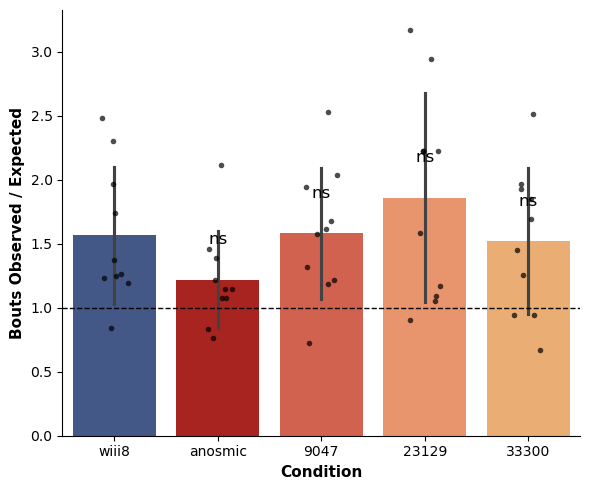

      comparison  mean_obs_over_exp    U        p significance
anosmic vs wiii8           1.220950 26.0 0.075442           ns
   9047 vs wiii8           1.582757 51.0 0.969850           ns
  23129 vs wiii8           1.860377 54.0 0.791030           ns
  33300 vs wiii8           1.522423 49.0 0.969839           ns


In [9]:
# Each real dish divided by its own genotype's pseudo mean, so the genotypes can be compared.
pseudo_mean_count = (
    bout_counts[bout_counts['source'] == 'pseudo']
    .groupby('condition')['n_bouts']
    .mean()
    .rename('pseudo_mean')
)

ratio_count = bout_counts[bout_counts['source'] == 'real'].merge(pseudo_mean_count, on='condition')
ratio_count['obs_over_exp'] = ratio_count['n_bouts'] / ratio_count['pseudo_mean']

control = ratio_count.loc[ratio_count['condition'] == 'wiii8', 'obs_over_exp']
stats_rows = []

for condition in conditions:
    if condition == 'wiii8':
        continue

    test_group = ratio_count.loc[ratio_count['condition'] == condition, 'obs_over_exp']
    u_stat, p_value = mannwhitneyu(test_group, control, alternative='two-sided')
    stars = '***' if p_value < 0.001 else '**' if p_value < 0.01 else '*' if p_value < 0.05 else 'ns'

    stats_rows.append({
        'comparison': f'{condition} vs wiii8',
        'mean_obs_over_exp': test_group.mean(),
        'U': u_stat,
        'p': p_value,
        'significance': stars,
    })

plt.figure(figsize=(6, 5))

ax = sns.barplot(
    data=ratio_count, x='condition', y='obs_over_exp', order=conditions,
    hue='condition', hue_order=conditions, palette=condition_colors,
    errorbar='sd', legend=False,
)
sns.stripplot(
    data=ratio_count, x='condition', y='obs_over_exp', order=conditions,
    color='black', size=4, jitter=0.15, alpha=0.7, ax=ax,
)

# Chance level: as many contacts as movement alone predicts.
ax.axhline(1, color='black', linestyle='--', linewidth=1)

y_offset = ratio_count['obs_over_exp'].max() * 0.08
for row in stats_rows:
    condition = row['comparison'].split(' vs ')[0]
    x = conditions.index(condition)
    y = ratio_count.loc[ratio_count['condition'] == condition, 'obs_over_exp'].mean() + y_offset
    ax.text(x, y, row['significance'], ha='center', va='bottom', fontsize=12)

plt.ylim(0, None)
plt.ylabel('Bouts Observed / Expected', fontsize=11, fontweight='bold')
plt.xlabel('Condition', fontsize=11, fontweight='bold')
sns.despine()
plt.tight_layout()
plt.savefig(f'{plot_dir}/pseudo_obs_over_exp_count.pdf', format='pdf')
plt.show()

print(pd.DataFrame(stats_rows).to_string(index=False))

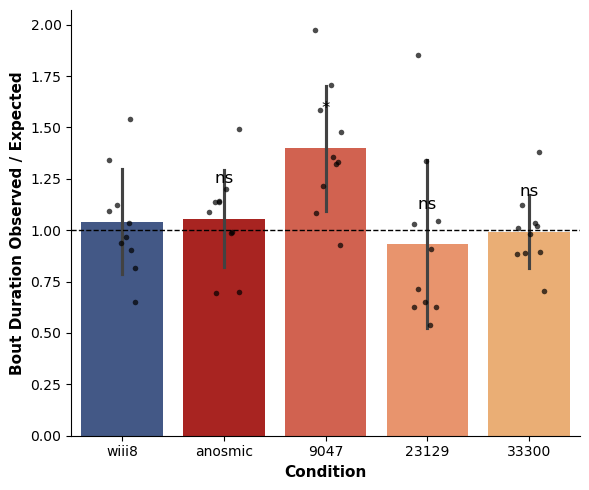

      comparison  mean_obs_over_exp    U        p significance
anosmic vs wiii8           1.056908 59.0 0.520523           ns
   9047 vs wiii8           1.398491 81.0 0.021134            *
  23129 vs wiii8           0.932653 34.0 0.241322           ns
  33300 vs wiii8           0.992662 43.0 0.623176           ns


In [10]:
# Same ratio for bout duration.
pseudo_mean_duration = (
    duration_per_file[duration_per_file['source'] == 'pseudo']
    .groupby('condition')['mean_bout_duration']
    .mean()
    .rename('pseudo_mean')
)

ratio_duration = duration_per_file[duration_per_file['source'] == 'real'].merge(pseudo_mean_duration, on='condition')
ratio_duration['obs_over_exp'] = ratio_duration['mean_bout_duration'] / ratio_duration['pseudo_mean']

control = ratio_duration.loc[ratio_duration['condition'] == 'wiii8', 'obs_over_exp']
stats_rows = []

for condition in conditions:
    if condition == 'wiii8':
        continue

    test_group = ratio_duration.loc[ratio_duration['condition'] == condition, 'obs_over_exp']
    u_stat, p_value = mannwhitneyu(test_group, control, alternative='two-sided')
    stars = '***' if p_value < 0.001 else '**' if p_value < 0.01 else '*' if p_value < 0.05 else 'ns'

    stats_rows.append({
        'comparison': f'{condition} vs wiii8',
        'mean_obs_over_exp': test_group.mean(),
        'U': u_stat,
        'p': p_value,
        'significance': stars,
    })

plt.figure(figsize=(6, 5))

ax = sns.barplot(
    data=ratio_duration, x='condition', y='obs_over_exp', order=conditions,
    hue='condition', hue_order=conditions, palette=condition_colors,
    errorbar='sd', legend=False,
)
sns.stripplot(
    data=ratio_duration, x='condition', y='obs_over_exp', order=conditions,
    color='black', size=4, jitter=0.15, alpha=0.7, ax=ax,
)

ax.axhline(1, color='black', linestyle='--', linewidth=1)

y_offset = ratio_duration['obs_over_exp'].max() * 0.08
for row in stats_rows:
    condition = row['comparison'].split(' vs ')[0]
    x = conditions.index(condition)
    y = ratio_duration.loc[ratio_duration['condition'] == condition, 'obs_over_exp'].mean() + y_offset
    ax.text(x, y, row['significance'], ha='center', va='bottom', fontsize=12)

plt.ylim(0, None)
plt.ylabel('Bout Duration Observed / Expected', fontsize=11, fontweight='bold')
plt.xlabel('Condition', fontsize=11, fontweight='bold')
sns.despine()
plt.tight_layout()
plt.savefig(f'{plot_dir}/pseudo_obs_over_exp_duration.pdf', format='pdf')
plt.show()

print(pd.DataFrame(stats_rows).to_string(index=False))